# imports

In [56]:
import math
from pathlib import Path

from jaxtyping import Float
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.decomposition import PCA

# muutils
import muutils.tensor_info
from muutils.dbg import dbg, dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import null_stats, filter_data, normalize_data
from attention_motifs.features.plotting import (
	plot_embedding,
	apply_pca,
	plot_correlation_matrix,
)
from attention_motifs.bins import Bins
from attention_motifs.features.features import scalar_feature_table, compute_scalar_features
from attention_motifs.features.hist_beta_fit import hist_beta_fit
from attention_motifs.util import prefix_dict
from attention_motifs.features.transition_tensor import tt_features
from attention_motifs.features.vec_features import vec_features
from attention_motifs.math.cos_sim import cosine_similarity_matrix
from attention_motifs.math.math import skew_lt

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [87]:
pl.Config.set_tbl_rows(100)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/features/")

In [4]:
# raw data from file instead of regenerating
DATA_RAW = pl.read_ndjson(PATH_BASE / "raw.jsonl")

# basic data inspection

In [ ]:
display(DATA_RAW)
display(set(DATA_RAW.dtypes))
display(DATA_RAW.head())
display(DATA_RAW.describe())
# print unique values for columns which start with "activations"
print(f"{DATA_RAW['activation.model'].unique() = }")
for col in DATA_RAW.columns:
    if col.startswith("activation"):
        print(f"{col = }")
display(null_stats(DATA_RAW))

feat.markov_transition.env.upper.intercept,feat.markov_transition.diff.zero_crossing_rate,feat.markov_transition.time.L1_norm,feat.markov_transition.diff.linreg.intercept,feat.gram.col.beta_hist.hist.raw.linreg.slope,feat.diag.L2_norm,feat.log.gram.col.beta_hist.hist.raw.std,feat.log.gram.col.beta_hist.hist.raw.kurtosis,feat.log.gram.col.beta_hist.hist.raw.energy,feat.log.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.markov_transition.time.kurtosis,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.energy,feat.gram.skew.beta_hist.hist.raw.L2_norm,feat.first_tok.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.median,feat.diag.entropy,feat.markov_transition.time.zero_crossing_rate,feat.markov_transition.diff.entropy,feat.gram.skew.beta_hist.hist.raw.std,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.col.beta_hist.hist.raw.entropy,feat.first_tok.entropy,feat.markov_transition.diff.rms,feat.log.gram.row.beta_hist.hist.raw.variance,feat.log.gram.skew.beta_hist.hist.raw.rms,feat.markov_transition.time.skewness,feat.log.gram.skew.beta_hist.hist.raw.energy,feat.log.gram.row.beta_hist.hist.raw.entropy,feat.markov_transition.env.upper.slope,activation.cls,feat.diag.energy,feat.markov_transition.diff.mean,feat.gram.row.beta_hist.hist.raw.energy,feat.first_tok.L2_norm,…,feat.gram.row.beta_hist.hist.raw.median,feat.diag.zero_crossing_rate,feat.gram.col.beta_hist.hist.raw.L2_norm,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.markov_transition.time.std,feat.log.gram.row.beta_hist.hist.raw.median,feat.gram.skew.beta_hist.hist.raw.entropy,feat.first_tok.median,feat.gram.col.beta_hist.hist.raw.energy,activation.prompt,feat.log.gram.col.beta_hist.hist.raw.variance,feat.log.gram.skew.beta_hist.hist.raw.kurtosis,feat.markov_transition.time.mean,feat.gram.col.beta_hist.hist.raw.kurtosis,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.log.gram.skew.beta_hist.hist.raw.linreg.slope,feat.log.gram.col.beta_hist.hist.raw.L1_norm,feat.markov_transition.diff.L1_norm,feat.diag.autocorr_lag1,feat.diag.variance,feat.markov_transition.env.lower.intercept,feat.markov_transition.env.upper.r2,feat.gram.row.beta_hist.hist.raw.zero_crossing_rate,feat.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.row.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.rms,feat.log.gram.col.beta_hist.hist.raw.skewness,feat.log.gram.skew.beta_hist.hist.raw.L1_norm,feat.first_tok.kurtosis,feat.markov_transition.diff.variance,feat.markov_transition.time.entropy,feat.markov_transition.env.lower.r2,feat.markov_transition.time.variance,feat.diag.rms,feat.markov_transition.diff.std,feat.markov_transition.diff.L2_norm
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.034932,-5.94881,0.022139,0.727349,21.737763,17.271027,-0.025481,null,0.859375,18.311236,19.709615,0.303453,0.22674,2.15858,0.0,0.073066,107.532616,0.742355,-0.290582,111.494417,0.39979,1.140814,0.094072,0.563191,3.151275,null,317.777149,0.39979,0.0,"""pythia-14m:L0:H0""",6.369844,0.00885,30430.265188,0.017348,…,8.855091,0.0,16.632153,0.029031,0.0,0.0,0.644974,0.007402,283267.602806,"""MjWkadUxH4Z5nfLEFtUc1w""",0.529036,25.775427,0.0,12.415323,4.927002,-0.055552,0.164973,0.00885,0.158451,0.027237,0.0,1.0,0.0,35.058429,20.142488,0.163203,0.756456,4.743038,0.931865,12.67031,0.00885,0.0,1.0,0.0,0.236381,0.094072,0.00885
0.0,0.0,0.0,0.034932,-5.743424,0.035387,0.81665,26.369746,21.489523,-0.198448,null,0.799153,23.757939,24.856884,0.134462,0.540372,2.593486,0.0,0.073066,138.583471,0.699571,-0.285403,140.611772,0.39979,0.560997,0.094072,0.740779,3.168083,null,321.176074,0

{Float64, Int64, String}

feat.markov_transition.env.upper.intercept,feat.markov_transition.diff.zero_crossing_rate,feat.markov_transition.time.L1_norm,feat.markov_transition.diff.linreg.intercept,feat.gram.col.beta_hist.hist.raw.linreg.slope,feat.diag.L2_norm,feat.log.gram.col.beta_hist.hist.raw.std,feat.log.gram.col.beta_hist.hist.raw.kurtosis,feat.log.gram.col.beta_hist.hist.raw.energy,feat.log.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.markov_transition.time.kurtosis,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.energy,feat.gram.skew.beta_hist.hist.raw.L2_norm,feat.first_tok.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.median,feat.diag.entropy,feat.markov_transition.time.zero_crossing_rate,feat.markov_transition.diff.entropy,feat.gram.skew.beta_hist.hist.raw.std,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.col.beta_hist.hist.raw.entropy,feat.first_tok.entropy,feat.markov_transition.diff.rms,feat.log.gram.row.beta_hist.hist.raw.variance,feat.log.gram.skew.beta_hist.hist.raw.rms,feat.markov_transition.time.skewness,feat.log.gram.skew.beta_hist.hist.raw.energy,feat.log.gram.row.beta_hist.hist.raw.entropy,feat.markov_transition.env.upper.slope,activation.cls,feat.diag.energy,feat.markov_transition.diff.mean,feat.gram.row.beta_hist.hist.raw.energy,feat.first_tok.L2_norm,…,feat.gram.row.beta_hist.hist.raw.median,feat.diag.zero_crossing_rate,feat.gram.col.beta_hist.hist.raw.L2_norm,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.markov_transition.time.std,feat.log.gram.row.beta_hist.hist.raw.median,feat.gram.skew.beta_hist.hist.raw.entropy,feat.first_tok.median,feat.gram.col.beta_hist.hist.raw.energy,activation.prompt,feat.log.gram.col.beta_hist.hist.raw.variance,feat.log.gram.skew.beta_hist.hist.raw.kurtosis,feat.markov_transition.time.mean,feat.gram.col.beta_hist.hist.raw.kurtosis,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.log.gram.skew.beta_hist.hist.raw.linreg.slope,feat.log.gram.col.beta_hist.hist.raw.L1_norm,feat.markov_transition.diff.L1_norm,feat.diag.autocorr_lag1,feat.diag.variance,feat.markov_transition.env.lower.intercept,feat.markov_transition.env.upper.r2,feat.gram.row.beta_hist.hist.raw.zero_crossing_rate,feat.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.row.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.rms,feat.log.gram.col.beta_hist.hist.raw.skewness,feat.log.gram.skew.beta_hist.hist.raw.L1_norm,feat.first_tok.kurtosis,feat.markov_transition.diff.variance,feat.markov_transition.time.entropy,feat.markov_transition.env.lower.r2,feat.markov_transition.time.variance,feat.diag.rms,feat.markov_transition.diff.std,feat.markov_transition.diff.L2_norm
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.034932,-5.94881,0.022139,0.727349,21.737763,17.271027,-0.025481,null,0.859375,18.311236,19.709615,0.303453,0.22674,2.15858,0.0,0.073066,107.532616,0.742355,-0.290582,111.494417,0.39979,1.140814,0.094072,0.563191,3.151275,null,317.777149,0.39979,0.0,"""pythia-14m:L0:H0""",6.369844,0.00885,30430.265188,0.017348,…,8.855091,0.0,16.632153,0.029031,0.0,0.0,0.644974,0.007402,283267.602806,"""MjWkadUxH4Z5nfLEFtUc1w""",0.529036,25.775427,0.0,12.415323,4.927002,-0.055552,0.164973,0.00885,0.158451,0.027237,0.0,1.0,0.0,35.058429,20.142488,0.163203,0.756456,4.743038,0.931865,12.67031,0.00885,0.0,1.0,0.0,0.236381,0.094072,0.00885
0.0,0.0,0.0,0.034932,-5.743424,0.035387,0.81665,26.369746,21.489523,-0.198448,null,0.799153,23.757939,24.856884,0.134462,0.540372,2.593486,0.0,0.073066,138.583471,0.699571,-0.285403,140.611772,0.39979,0.560997,0.094072,0.740779,3.168083,null,321.176074,0

statistic,feat.markov_transition.env.upper.intercept,feat.markov_transition.diff.zero_crossing_rate,feat.markov_transition.time.L1_norm,feat.markov_transition.diff.linreg.intercept,feat.gram.col.beta_hist.hist.raw.linreg.slope,feat.diag.L2_norm,feat.log.gram.col.beta_hist.hist.raw.std,feat.log.gram.col.beta_hist.hist.raw.kurtosis,feat.log.gram.col.beta_hist.hist.raw.energy,feat.log.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.markov_transition.time.kurtosis,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.energy,feat.gram.skew.beta_hist.hist.raw.L2_norm,feat.first_tok.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.median,feat.diag.entropy,feat.markov_transition.time.zero_crossing_rate,feat.markov_transition.diff.entropy,feat.gram.skew.beta_hist.hist.raw.std,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.col.beta_hist.hist.raw.entropy,feat.first_tok.entropy,feat.markov_transition.diff.rms,feat.log.gram.row.beta_hist.hist.raw.variance,feat.log.gram.skew.beta_hist.hist.raw.rms,feat.markov_transition.time.skewness,feat.log.gram.skew.beta_hist.hist.raw.energy,feat.log.gram.row.beta_hist.hist.raw.entropy,feat.markov_transition.env.upper.slope,activation.cls,feat.diag.energy,feat.markov_transition.diff.mean,feat.gram.row.beta_hist.hist.raw.energy,…,feat.gram.row.beta_hist.hist.raw.median,feat.diag.zero_crossing_rate,feat.gram.col.beta_hist.hist.raw.L2_norm,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.markov_transition.time.std,feat.log.gram.row.beta_hist.hist.raw.median,feat.gram.skew.beta_hist.hist.raw.entropy,feat.first_tok.median,feat.gram.col.beta_hist.hist.raw.energy,activation.prompt,feat.log.gram.col.beta_hist.hist.raw.variance,feat.log.gram.skew.beta_hist.hist.raw.kurtosis,feat.markov_transition.time.mean,feat.gram.col.beta_hist.hist.raw.kurtosis,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.log.gram.skew.beta_hist.hist.raw.linreg.slope,feat.log.gram.col.beta_hist.hist.raw.L1_norm,feat.markov_transition.diff.L1_norm,feat.diag.autocorr_lag1,feat.diag.variance,feat.markov_transition.env.lower.intercept,feat.markov_transition.env.upper.r2,feat.gram.row.beta_hist.hist.raw.zero_crossing_rate,feat.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.row.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.rms,feat.log.gram.col.beta_hist.hist.raw.skewness,feat.log.gram.skew.beta_hist.hist.raw.L1_norm,feat.first_tok.kurtosis,feat.markov_transition.diff.variance,feat.markov_transition.time.entropy,feat.markov_transition.env.lower.r2,feat.markov_transition.time.variance,feat.diag.rms,feat.markov_transition.diff.std,feat.markov_transition.diff.L2_norm
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,829.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,829.0,123872.0,123872.0,123872.0,"""123872""",123872.0,123872.0,123872.0,…,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,"""123872""",123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,123043.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,123043.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0

DATA_RAW['activation.model'].unique() = shape: (6,)
Series: 'activation.model' [str]
[
	"gpt2-medium"
	"gpt2-small"
	"gemma-2b"
	"tiny-stories-1M"
	"pythia-1b"
	"pythia-14m"
]
col = 'activation.cls'
col = 'activation.layer'
col = 'activation.cache_key'
col = 'activation.model'
col = 'activation.head'
col = 'activation.n_ctx'
col = 'activation.prompt'


feature,missing_count,missing_frac
str,i64,f64
"""feat.markov_transition.time.ku…",123043,0.993308
"""feat.markov_transition.time.sk…",123043,0.993308
"""feat.markov_transition.env.upp…",0,0.0
"""feat.markov_transition.diff.ze…",0,0.0
"""feat.markov_transition.time.L1…",0,0.0
…,…,…
"""feat.markov_transition.env.low…",0,0.0
"""feat.markov_transition.time.va…",0,0.0
"""feat.diag.rms""",0,0.0


# filter nans and certain models

In [6]:
# this will filter all-nan rows
DATA_FILTERED: pl.DataFrame = filter_data(
	DATA_RAW,
	# tinystories and small pythia models look very different in embedding space, so we get rid of them
	remove_models=["tiny-stories-1M", "pythia-14m"],
)
null_stats(DATA_FILTERED)

Removing 2 models: ['tiny-stories-1M', 'pythia-14m']
Removed 19456/123872 rows
Removing 37/176 feat.* columns due to zero variance or excessive missing values
feat.markov_transition.env.upper.intercept                   μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.diff.zero_crossing_rate               μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.L1_norm                          μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.kurtosis                         🚨 all NaN shape=104416 dtype=float64
feat.markov_transition.time.zero_crossing_rate               μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.skewness                         🚨 all NaN shape=104416 dtype=float64
feat.markov_transition.env.upper.slope                       μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.di

feature,missing_count,missing_frac
str,i64,f64
"""feat.markov_transition.diff.li…",0,0.0
"""feat.gram.col.beta_hist.hist.r…",0,0.0
"""feat.diag.L2_norm""",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
…,…,…
"""feat.first_tok.kurtosis""",0,0.0
"""feat.markov_transition.diff.va…",0,0.0
"""feat.diag.rms""",0,0.0


# scaling

In [68]:
# Pick feature columns
FEATURE_COLS: list[str] = [
	col for col in DATA_FILTERED.columns if col.startswith("feat.")
]
print(f"{FEATURE_COLS = }")

FEATURE_COLS = ['feat.markov_transition.diff.linreg.intercept', 'feat.gram.col.beta_hist.hist.raw.linreg.slope', 'feat.diag.L2_norm', 'feat.log.gram.col.beta_hist.hist.raw.std', 'feat.log.gram.col.beta_hist.hist.raw.kurtosis', 'feat.log.gram.col.beta_hist.hist.raw.energy', 'feat.log.gram.skew.beta_hist.hist.raw.autocorr_lag1', 'feat.log.gram.row.beta_hist.hist.raw.psd_total_power', 'feat.log.gram.row.beta_hist.hist.raw.energy', 'feat.gram.skew.beta_hist.hist.raw.L2_norm', 'feat.first_tok.linreg.r2', 'feat.log.gram.skew.beta_hist.hist.raw.median', 'feat.diag.entropy', 'feat.markov_transition.diff.entropy', 'feat.gram.skew.beta_hist.hist.raw.std', 'feat.gram.skew.beta_hist.hist.raw.autocorr_lag1', 'feat.log.gram.row.beta_hist.hist.raw.linreg.intercept', 'feat.gram.skew.beta_hist.hist.raw.rms', 'feat.log.gram.col.beta_hist.hist.raw.entropy', 'feat.first_tok.entropy', 'feat.markov_transition.diff.rms', 'feat.log.gram.row.beta_hist.hist.raw.variance', 'feat.log.gram.skew.beta_hist.hist.raw.

In [8]:
DATA_SCALED: pl.DataFrame
DATA_NORMS: pl.DataFrame
DATA_SCALED, DATA_NORMS = normalize_data(DATA_FILTERED, FEATURE_COLS)
DATA_NORMS.write_ndjson(PATH_BASE / "scaling.jsonl")

In [9]:
display(DATA_SCALED)
display(null_stats(DATA_SCALED))

feat.markov_transition.diff.linreg.intercept,feat.gram.col.beta_hist.hist.raw.linreg.slope,feat.diag.L2_norm,feat.log.gram.col.beta_hist.hist.raw.std,feat.log.gram.col.beta_hist.hist.raw.kurtosis,feat.log.gram.col.beta_hist.hist.raw.energy,feat.log.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.energy,feat.gram.skew.beta_hist.hist.raw.L2_norm,feat.first_tok.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.median,feat.diag.entropy,feat.markov_transition.diff.entropy,feat.gram.skew.beta_hist.hist.raw.std,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.col.beta_hist.hist.raw.entropy,feat.first_tok.entropy,feat.markov_transition.diff.rms,feat.log.gram.row.beta_hist.hist.raw.variance,feat.log.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.skew.beta_hist.hist.raw.energy,feat.log.gram.row.beta_hist.hist.raw.entropy,activation.cls,feat.diag.energy,feat.markov_transition.diff.mean,feat.gram.row.beta_hist.hist.raw.energy,feat.first_tok.L2_norm,feat.markov_transition.diff.linreg.r2,feat.gram.col.beta_hist.hist.raw.psd_total_power,feat.log.gram.skew.beta_hist.hist.raw.variance,feat.first_tok.mean,feat.gram.row.beta_hist.hist.raw.L1_norm,feat.log.gram.col.beta_hist.hist.raw.mean,feat.first_tok.rms,…,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.skew.beta_hist.hist.raw.mean,feat.diag.skewness,activation.n_ctx,feat.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.first_tok.linreg.intercept,feat.gram.col.beta_hist.hist.raw.variance,feat.gram.col.beta_hist.hist.raw.linreg.r2,feat.gram.skew.beta_hist.hist.raw.mean,feat.gram.skew.beta_hist.hist.raw.variance,feat.gram.row.beta_hist.hist.raw.median,feat.gram.col.beta_hist.hist.raw.L2_norm,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.gram.skew.beta_hist.hist.raw.entropy,feat.first_tok.median,feat.gram.col.beta_hist.hist.raw.energy,activation.prompt,feat.log.gram.col.beta_hist.hist.raw.variance,feat.log.gram.skew.beta_hist.hist.raw.kurtosis,feat.gram.col.beta_hist.hist.raw.kurtosis,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.log.gram.skew.beta_hist.hist.raw.linreg.slope,feat.log.gram.col.beta_hist.hist.raw.L1_norm,feat.markov_transition.diff.L1_norm,feat.diag.autocorr_lag1,feat.diag.variance,feat.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.row.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.rms,feat.log.gram.col.beta_hist.hist.raw.skewness,feat.log.gram.skew.beta_hist.hist.raw.L1_norm,feat.first_tok.kurtosis,feat.markov_transition.diff.variance,feat.diag.rms,feat.markov_transition.diff.std,feat.markov_transition.diff.L2_norm
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-0.263758,0.159702,0.28935,0.967734,0.634667,0.989938,4.061082,-0.687398,0.862457,0.992118,-0.77165,1.532475,0.963007,-0.245457,1.023283,-0.663572,0.724929,0.992118,-0.967268,0.604305,-0.21145,0.86094,-0.266664,-0.30592,-0.682661,"""gemma-2b:L0:H0""",0.065533,-0.266285,-0.238897,0.104872,-0.264634,-0.465602,-0.313089,0.24403,-0.288697,-0.818746,0.274522,…,-0.337689,-0.008704,-1.217447,109,-0.554036,0.155735,0.902994,-0.792824,-0.692114,0.987323,0.55133,0.870882,0.175968,-1.127713,0.435085,0.892255,"""MjWkadUxH4Z5nfLEFtUc1w""",0.988711,0.346838,0.796153,0.493229,0.210352,-0.818746,-0.266285,-0.451801,1.435507,-0.692114,-0.288697,-0.7244,0.839435,0.659782,-0.008704,-0.375439,-0.266285,0.442892,-0.21145,-0.266285
-0.263758,0.548083,-0.41691,1.041797,0.639603,1.070734,-0.687573,-0.687398,0.862457,1.636253,-1.136242,0.491825,-0.396461,-0.245457,1.647293,-1.046432,0.724929,1.636253,-0.967268,0.678459,-0.21145,0.86094,

feature,missing_count,missing_frac
str,i64,f64
"""feat.markov_transition.diff.li…",0,0.0
"""feat.gram.col.beta_hist.hist.r…",0,0.0
"""feat.diag.L2_norm""",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
…,…,…
"""feat.first_tok.kurtosis""",0,0.0
"""feat.markov_transition.diff.va…",0,0.0
"""feat.diag.rms""",0,0.0


In [10]:
DATA_SCALED.write_ndjson(PATH_BASE / "scaled.jsonl")

# covariance matrix

[ unknown ] unknown: μ=0.02 σ=0.44 x̃=-0.01 R=[-1.00,1.00] ℙ=|▆▆▇█▇▆▆| shape=(139,139) dtype=float64


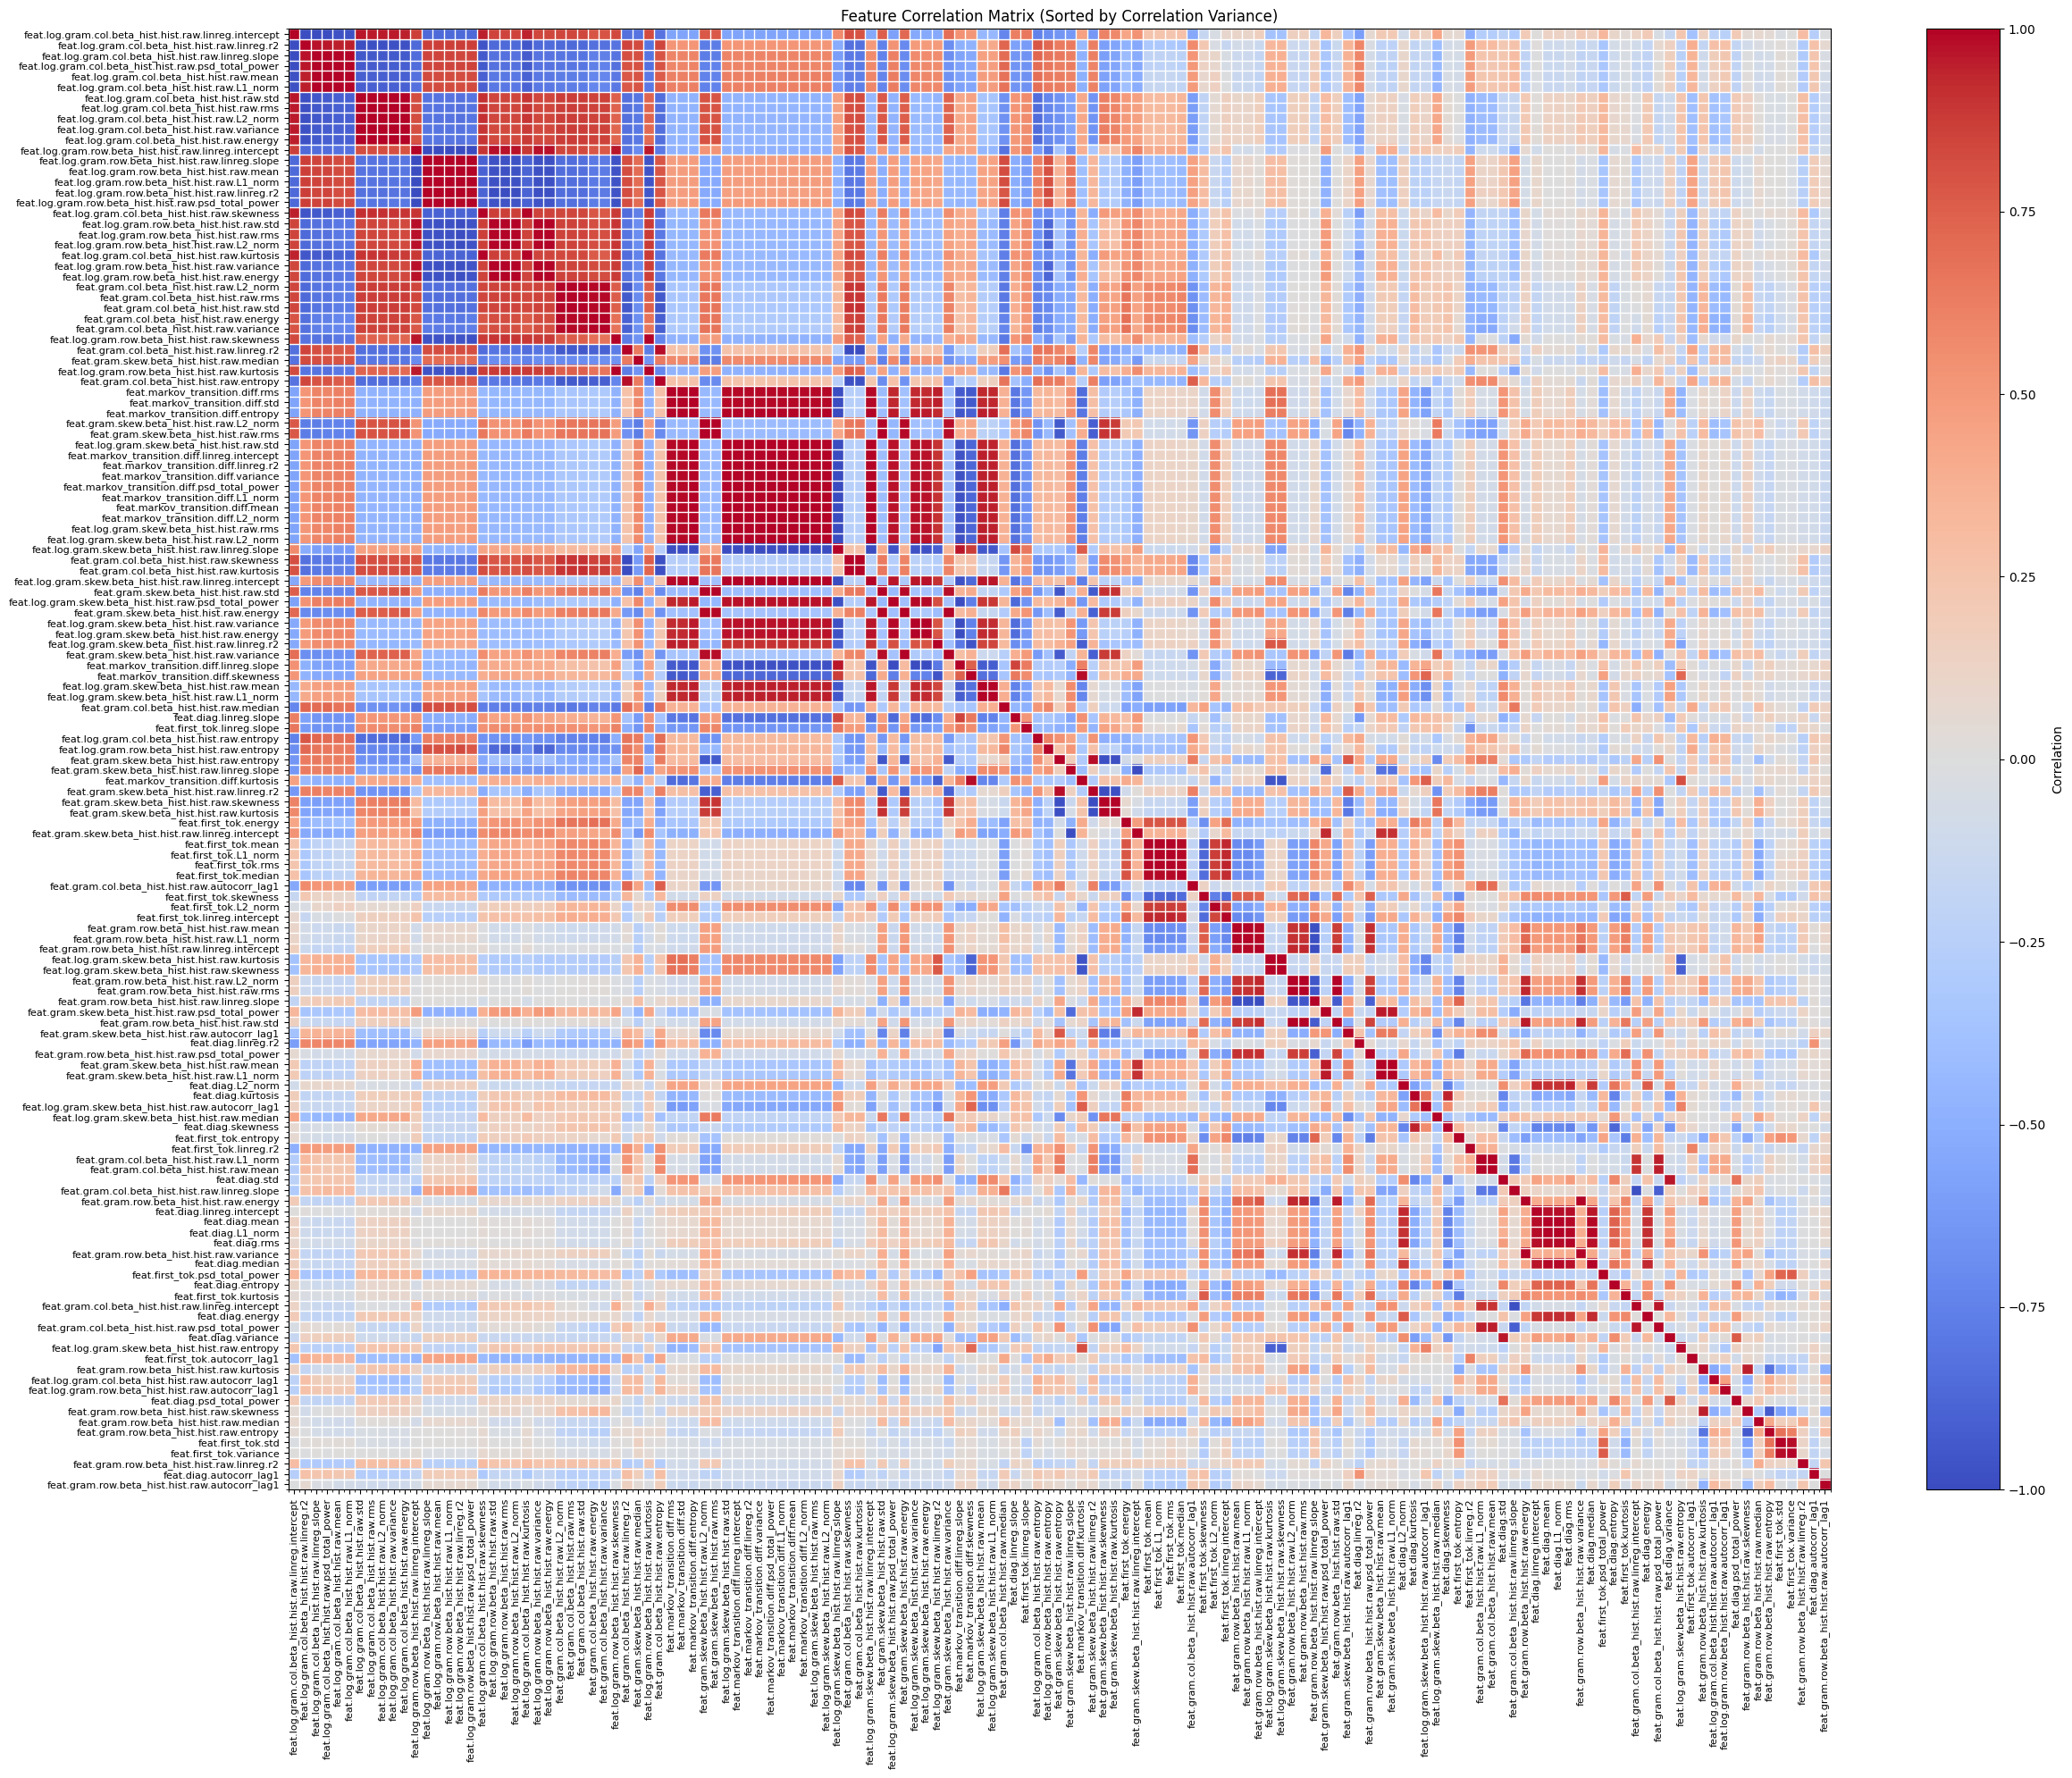

In [38]:
plot_correlation_matrix(
	DATA_SCALED,
	FEATURE_COLS,
	sort_by="var",
)

# PCA

[ <ipykernel>:2 ] DATA_SCALED[FEATURE_COLS].to_numpy(): μ=-0.00 σ=1.00 x̃=-0.16 R=[-16.09,25.89] ℙ=|▁▄█▆▃▂▁| shape=(104416,139) dtype=float64


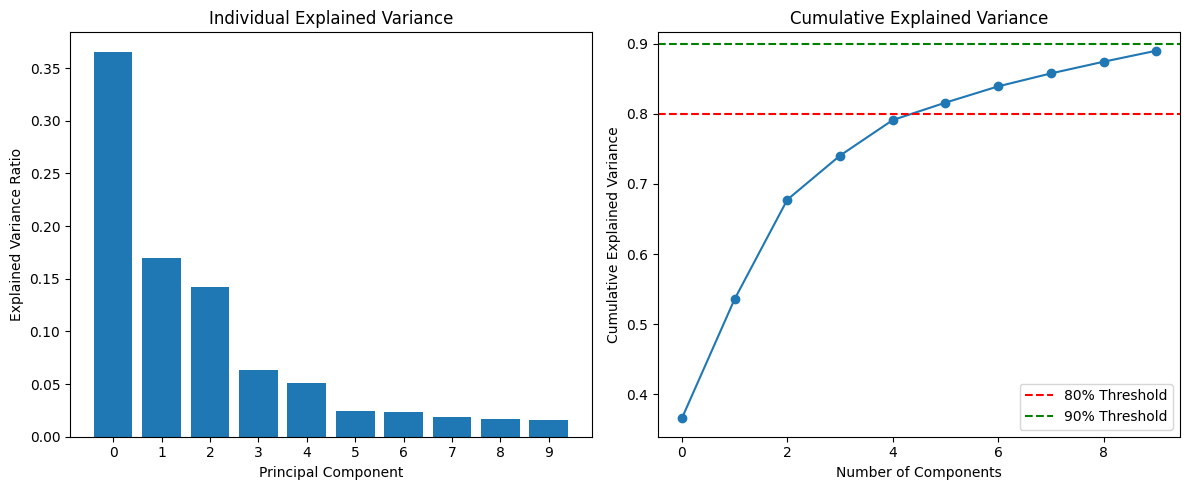

Number of components: 10
Total explained variance: 0.8901
Components needed for 80% variance: 6
Components needed for 90% variance: 1


In [98]:
# PCA
dbg_tensor(DATA_SCALED[FEATURE_COLS].to_numpy())
pca_data: np.ndarray
pca_obj: PCA
pca_data, pca_obj = apply_pca(DATA_SCALED, n_components=10, feature_cols=FEATURE_COLS)

In [99]:
# save pca data
dbg_tensor(pca_data)
np.save(PATH_BASE / "pca.npy", pca_data)

# only columns that start with "activation."
# for labelling the PCA plot in the webapp
data_meta: pl.DataFrame = DATA_SCALED[
	[col for col in DATA_SCALED.columns if col.startswith("activation.")]
]
data_meta = data_meta.write_ndjson(PATH_BASE / "meta.jsonl")

[ <ipykernel>:2 ] pca_data: μ=-0.00 σ=3.52 x̃=-0.07 R=[-35.88,27.20] ℙ=|▃▄▅█▇▅▄| shape=(104416,10) dtype=float64


In [100]:
dbg(len(FEATURE_COLS))
dbg_tensor(pca_obj.components_)

[ <ipykernel>:1 ] len(FEATURE_COLS) = 139
[ <ipykernel>:2 ] pca_obj.components_: μ=0.01 σ=0.08 x̃=0.00 R=[-0.30,0.31] ℙ=|▂▅▇█▇▅▂| shape=(10,139) dtype=float64


array([[-0.03726476, -0.00621194,  0.01775243, ..., -0.10443225,
        -0.10563372, -0.10443225],
       [ 0.12632746,  0.1373065 ,  0.12246848, ...,  0.01376333,
         0.01184514,  0.01376333],
       [ 0.06577452, -0.00404429, -0.00084675, ...,  0.14527854,
         0.14378221,  0.14527854],
       ...,
       [-0.07472039,  0.0823345 , -0.12037201, ..., -0.00371782,
         0.00019984, -0.00371782],
       [ 0.03042929,  0.04152931,  0.00610966, ..., -0.00629731,
         0.00109787, -0.00629731],
       [-0.03725055, -0.03944785,  0.04260461, ..., -0.0576868 ,
        -0.02630215, -0.0576868 ]])

In [107]:
def pca_importance_table(
    pca_obj: PCA,
    feature_names: list[str],
) -> pl.DataFrame:
    """Return PCA loadings plus simple importance stats.

    # Parameters:
     - `pca_obj : PCA`
        Fitted PCA.
     - `feature_names : list[str]`
        Columns used to fit the PCA.

    # Returns:
     - `pl.DataFrame`
        One row per feature; columns =
        `PC0 … PCk`, `abs_sum`, `abs_mean`, `abs_max`, `abs_var`, `var_weighted`.
    """
    # raw loadings → (n_features × n_components)
    loadings   = pca_obj.components_.T
    comp_cols  = [f"PC{i}" for i in range(pca_obj.n_components_)]
    df = (
        pl.DataFrame(loadings, schema=comp_cols)
        .with_columns(pl.Series("feature", feature_names))
        .select(["feature", *comp_cols])
    )

    abs_exprs = [pl.col(c).abs() for c in comp_cols]
    vw_exprs  = [
        pl.col(f"PC{i}").abs() * w
        for i, w in enumerate(pca_obj.explained_variance_ratio_)
    ]

    return (
        df.with_columns(
            abs_mean     = pl.sum_horizontal(abs_exprs) / len(comp_cols),
            abs_max      = pl.max_horizontal(abs_exprs),
            abs_var      = pl.concat_list(abs_exprs).list.var(ddof=0),  # replacement
            var_weighted = pl.sum_horizontal(vw_exprs),
        )
        .sort("abs_mean", descending=True)
    )


df_importance = pca_importance_table(
    pca_obj,
	feature_names=FEATURE_COLS,
)
df_importance.sort(pl.col("PC0").abs(), descending=True)

feature,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,abs_mean,abs_max,abs_var,var_weighted
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""feat.log.gram.col.beta_hist.hi…",0.132019,0.021744,0.041693,0.026644,0.050231,-0.039893,0.007525,-0.042993,0.002443,-0.043938,0.040912,0.132019,0.001157,0.064796
"""feat.log.gram.col.beta_hist.hi…",-0.131491,-0.023885,-0.029988,-0.027592,-0.058581,0.043806,-0.008661,0.040766,0.002672,0.049681,0.041712,0.131491,0.001168,0.063965
"""feat.log.gram.col.beta_hist.hi…",-0.130876,-0.018614,-0.028844,-0.032396,-0.062058,0.052676,-0.013077,0.043954,0.004689,0.046901,0.043409,0.130876,0.001146,0.063533
"""feat.log.gram.col.beta_hist.hi…",-0.130754,-0.016101,-0.057749,-0.021995,-0.035636,0.02978,0.002459,0.037141,-0.029938,0.037038,0.039859,0.130754,0.00111,0.064495
"""feat.log.gram.col.beta_hist.hi…",-0.12954,-0.02547,-0.019496,-0.0281,-0.065156,0.046702,-0.009547,0.038372,0.007077,0.054098,0.042356,0.12954,0.001163,0.062588
"""feat.log.gram.col.beta_hist.hi…",-0.12954,-0.02547,-0.019496,-0.0281,-0.065156,0.046702,-0.009547,0.038372,0.007077,0.054098,0.042356,0.12954,0.001163,0.062588
"""feat.log.gram.col.beta_hist.hi…",0.126696,0.028193,0.069269,0.003225,0.015781,0.005083,-0.016248,-0.03897,0.049178,-0.028481,0.038113,0.126696,0.001242,0.064441
"""feat.log.gram.col.beta_hist.hi…",0.126376,0.028487,0.070044,0.002476,0.014721,0.00655,-0.016804,-0.038966,0.050204,-0.027945,0.038257,0.126376,0.001242,0.064442
"""feat.log.gram.col.beta_hist.hi…",0.126376,0.028487,0.070044,0.002476,0.014721,0.00655,-0.016804,-0.038966,0.050204,-0.027945,0.038257,0.126376,0.001242,0.064442


In [94]:
import math
from collections import defaultdict
from statistics import mean, median
from typing import Iterable, Literal

import polars as pl
import numpy as np


Stat = Literal["mean", "min", "max", "median"]


def aggregate_feature_stats(
    df: pl.DataFrame,
    *,
    side: int|set[int] = -1,
    abs_col: str = "abs_mean",
    feature_col: str = "feature",
) -> pl.DataFrame:
    """Group by the first *or* last token of a dot-separated *feature* column
    and compute summary statistics for `abs_mean`.
    
    A minimal loop + `defaultdict` keeps things readable; only the final
    conversion to a `polars.DataFrame` uses Polars internals.

    # Parameters
     - `df : pl.DataFrame`  
       Input data with at least `feature_col` & `abs_col`.
     - `side : Literal["first", "last"]`  
       Which token to group on. (defaults to `"last"`)
     - `abs_col : str`  
       Numeric column to aggregate. (defaults to `"abs_mean"`)
     - `feature_col : str`  
       Dot-delimited feature names. (defaults to `"feature"`)

    # Returns
     - `pl.DataFrame`  
       One row per token, with the requested statistics.

    # Usage
    ```python
    out = aggregate_feature_stats(df, side="first", stats=("mean", "median"))
    ```

    # Raises
     - `ValueError` : invalid `side` or `stats` entry
    """
    # --- simple loop, no Polars “wizardry” ---------------------------------
    groups: defaultdict[str, list[float]] = defaultdict(list)

    feat_series = df[feature_col]          # pl.Series
    val_series = df[abs_col]               # pl.Series

    for feat, val in zip(feat_series, val_series, strict=False):
        if val is None or (isinstance(val, float) and math.isnan(val)):
            continue  # skip nulls/NaNs
        token: str
        if isinstance(side, int):
            token = feat.split(".")[side]
        else:
            token = ".".join([
                s 
                for i,s in enumerate(feat.split("."))
                if i in side
            ])
        groups[token].append(float(val))

    # --- compute requested statistics --------------------------------------
    rows: list[dict[str, float | str]] = []
    for token, values in groups.items():
        vals_np: np.ndarray = np.asarray(values, dtype=float)
        row: dict[str, float | str] = {"token": token}
        row["mean"] = float(vals_np.mean())
        row["min"] = float(vals_np.min())
        row["max"] = float(vals_np.max())
        row["median"] = float(median(values))  # statistics.median faster than np
        rows.append(row)

    # convert back to Polars for downstream work
    return pl.DataFrame(rows)

display(aggregate_feature_stats(df_importance, side=1).sort("max", descending=True))

token,mean,min,max,median
str,f64,f64,f64,f64
"""first_tok""",0.075287,0.049504,0.118228,0.06668
"""gram""",0.06981,0.03859,0.100537,0.07101
"""log""",0.05608,0.038113,0.100355,0.055813
"""diag""",0.081186,0.066255,0.091967,0.081856
"""markov_transition""",0.047135,0.038061,0.080438,0.042245


/tmp/ipykernel_557721/1721246274.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


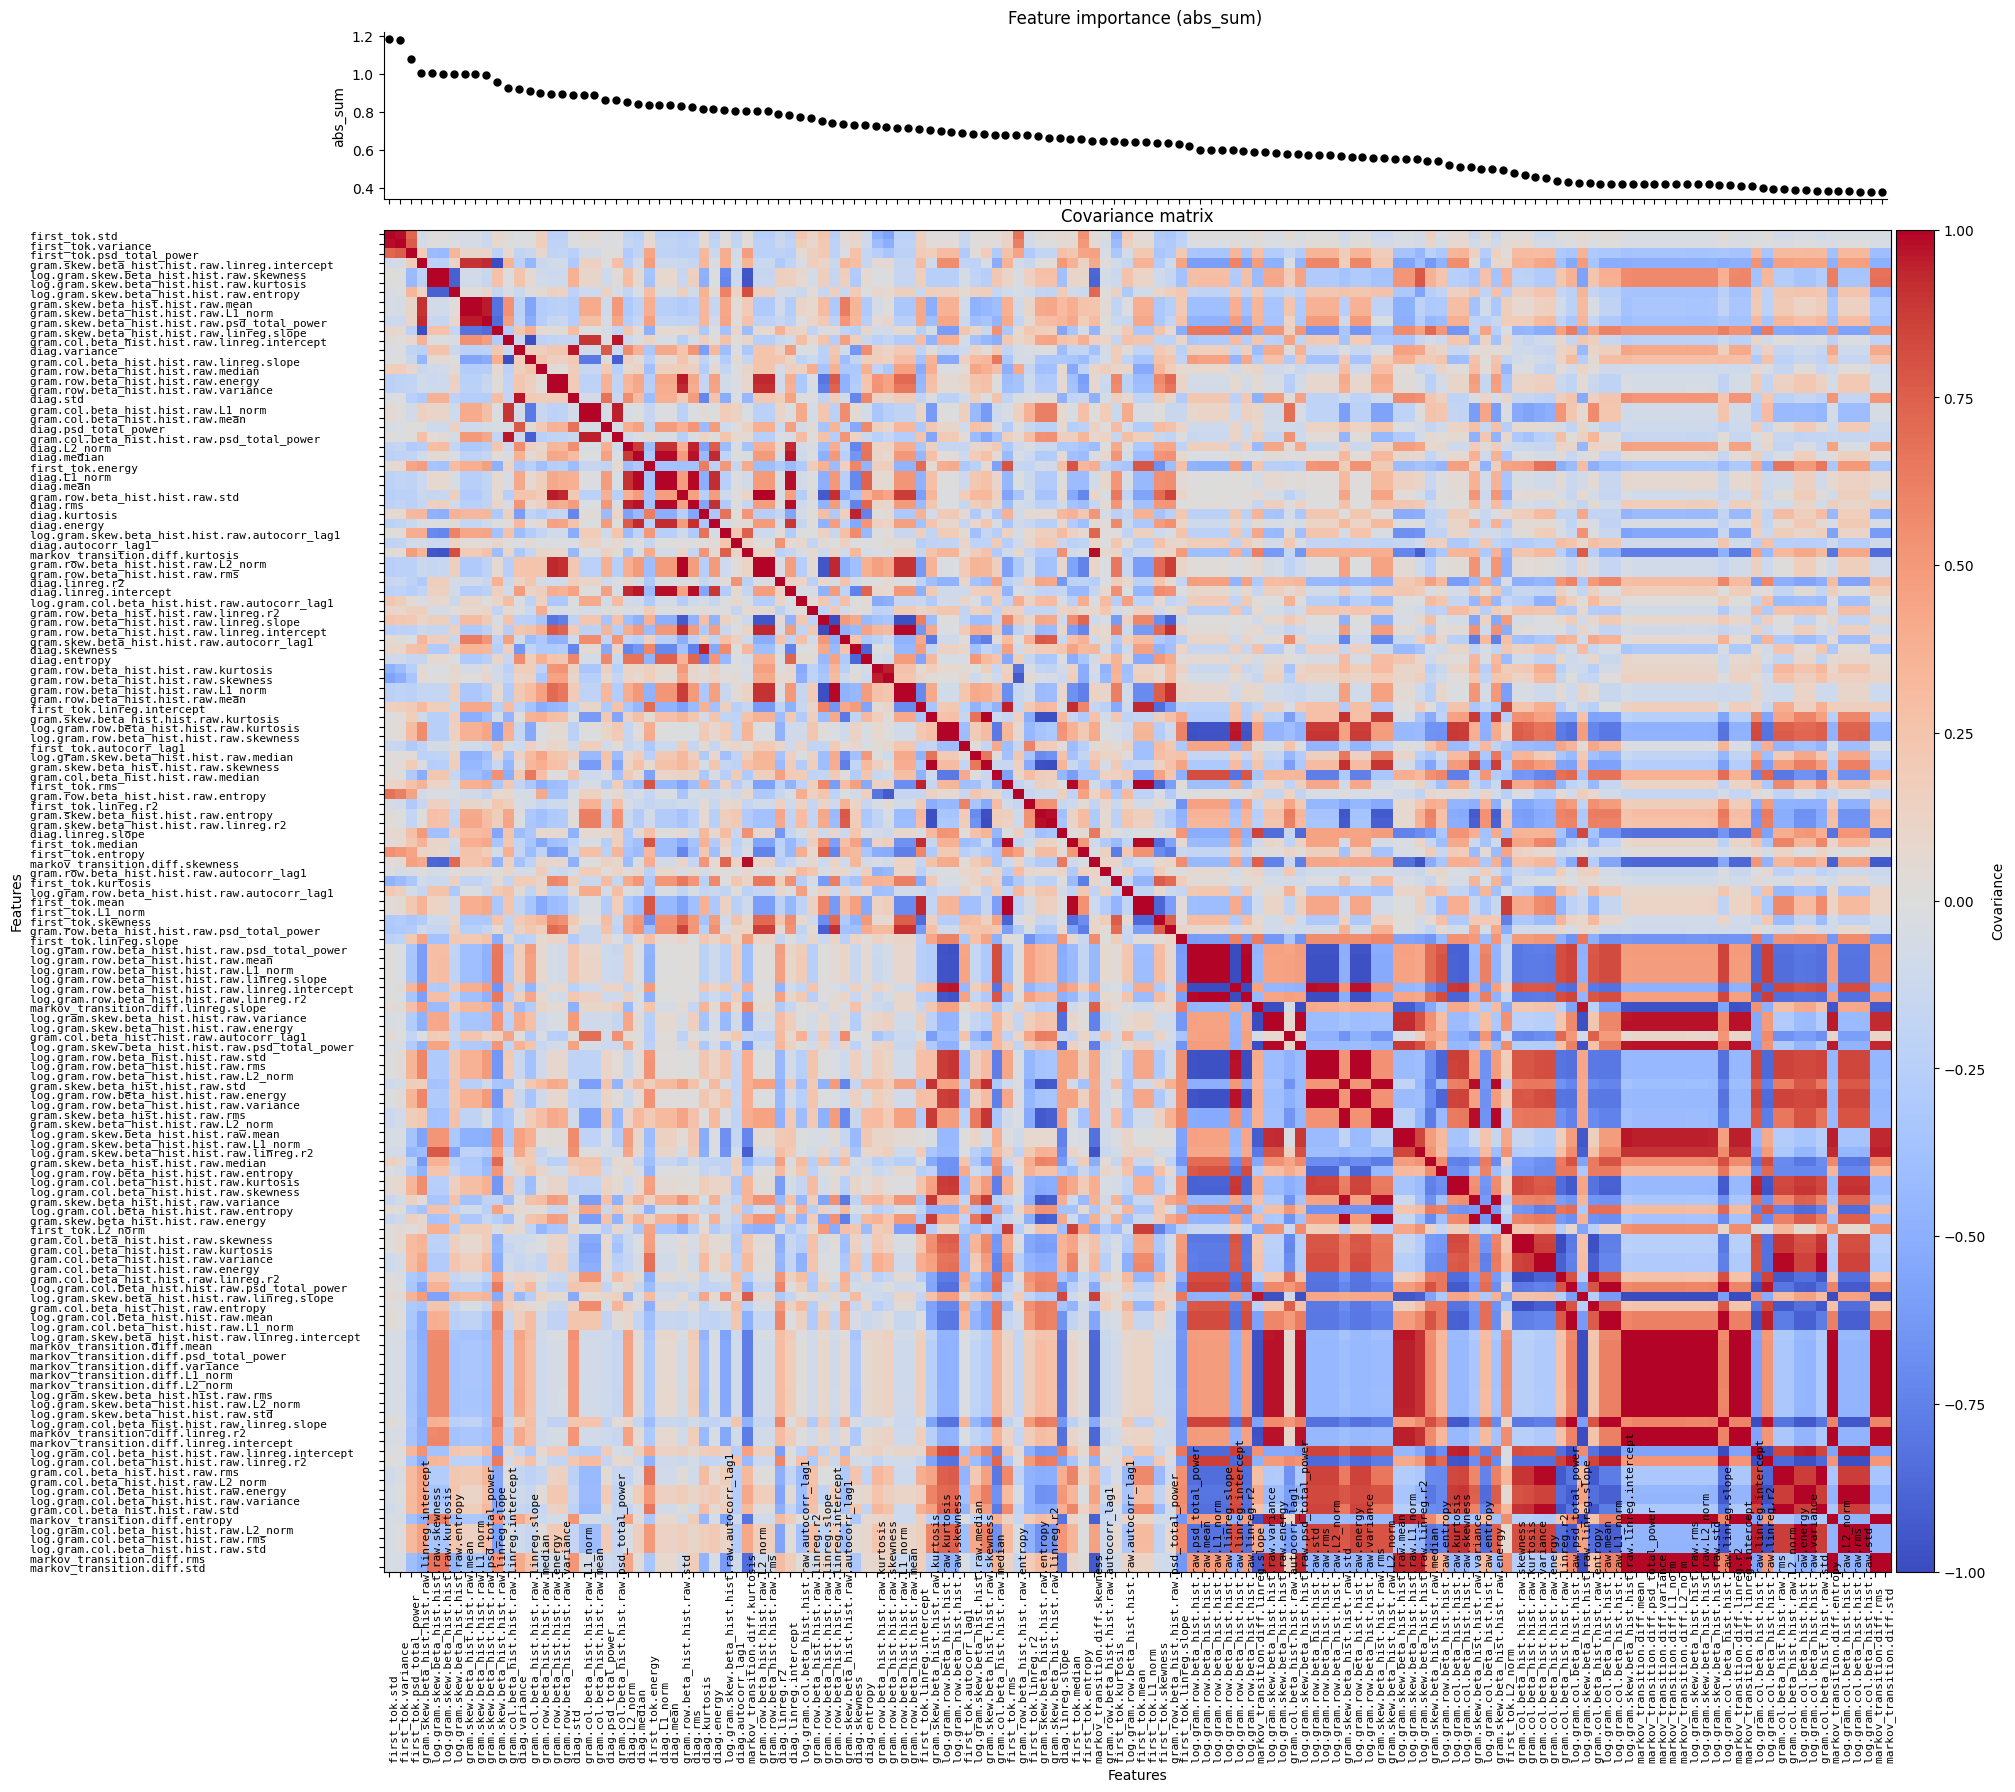

In [92]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ------------------------------------------------------------------------
MONO_FONT   = "DejaVu Sans Mono"   # any monospace installed on your system
PAD_CHARS   = 2                    # add this many spaces **beyond** max length
# ------------------------------------------------------------------------


def plot_importance_covariance(
    data: pl.DataFrame,
    importance_df: pl.DataFrame,
    metric: str = "abs_sum",
    descending: bool = True,
    feature_order: list[str] | None = None,   # << NEW
    bins: int | None = None,
    cmap: str = "coolwarm",
    feat_strip_prefix: str = "feat.",
    figsize: tuple[int, int] = (25, 22),
    trim_frac: float = 0.03,
    tick_pad: int = 10,                       # << NEW (points; moves x-labels down)
) -> None:
    # ---------- pick feature sequence ------------------------------------
    if feature_order is not None:
        # Use the given list exactly as provided
        features = feature_order
        # Grab importance scores in that order (fill with NaNs if missing)
        scores_df = (
            pl.DataFrame({"feature": features})
            .join(importance_df.select("feature", metric), on="feature", how="left")
        )
    else:
        # Fall back to importance-sorted order
        scores_df = importance_df.sort(metric, descending=descending).select("feature", metric)
        features  = scores_df["feature"].to_list()

    scores = scores_df[metric].to_numpy()
    labels = [f.removeprefix(feat_strip_prefix) for f in features]

    # ---------- monospace + right-padding for labels ----------------------
    max_len   = max(len(lbl) for lbl in labels) + PAD_CHARS
    pad_lbls  = [lbl.ljust(max_len) for lbl in labels]

    # ---------- covariance ------------------------------------------------
    cov   = np.cov(data[features].to_numpy().T, bias=False)
    vmax  = np.nanmax(np.abs(cov)) or 1.0

    # ---------- figure / grid --------------------------------------------
    ncols = 2 if bins else 1
    gs = gridspec.GridSpec(
        2, ncols,
        height_ratios=[1, 8],
        width_ratios=[20, 5] if bins else [20],
        hspace=0.04, wspace=0.3,
    )
    fig = plt.figure(figsize=figsize)

    # ---------- covariance heat-map --------------------------------------
    ax_cov = fig.add_subplot(gs[1, 0])
    im     = ax_cov.imshow(cov, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")

    ax_cov.set_xticks(range(len(features)))
    ax_cov.set_yticks(range(len(features)))
    ax_cov.set_xticklabels(
        pad_lbls,
        rotation=90,
        rotation_mode="anchor",
        fontfamily=MONO_FONT,
        fontsize=8,
    )
    ax_cov.set_yticklabels(
        pad_lbls,
        fontfamily=MONO_FONT,
        fontsize=8,
    )
    ax_cov.tick_params(axis="x", pad=tick_pad)   # << shift labels downward

    ax_cov.set_xlabel("Features")
    ax_cov.set_ylabel("Features")
    ax_cov.set_title("Covariance matrix")

    divider = make_axes_locatable(ax_cov)
    cax     = divider.append_axes("right", size="2.5%", pad=0.05)
    fig.colorbar(im, cax=cax).set_label("Covariance")

    # ---------- importance dot-plot (shares x) ---------------------------
    ax_imp = fig.add_subplot(gs[0, 0], sharex=ax_cov)
    ax_imp.plot(np.arange(len(scores)), scores, "o", markersize=5, color="black")
    ax_imp.set_ylabel(metric)
    ax_imp.set_title(f"Feature importance ({metric})")
    ax_imp.tick_params(axis="x", labelbottom=False)
    for spine in ("top", "right"):
        ax_imp.spines[spine].set_visible(False)
    ax_imp.margins(x=0)

    if 0 < trim_frac < 0.5:
        pos = ax_imp.get_position()
        ax_imp.set_position([pos.x0, pos.y0, pos.width * (1 - trim_frac), pos.height])

    # ---------- optional histogram ---------------------------------------
    if bins:
        ax_hist = fig.add_subplot(gs[:, 1])
        ax_hist.hist(scores, bins=bins, orientation="horizontal", color="gray")
        ax_hist.set_xlabel("count")
        ax_hist.set_ylabel(metric)
        ax_hist.set_title("Importance distribution")
        ax_hist.invert_yaxis()

    plt.tight_layout()
    plt.show()

plot_importance_covariance(
    DATA_SCALED,
    df_importance,
    # feature_order=sorted(FEATURE_COLS, key=lambda x: x.split(".")[-1]),
    metric="abs_sum",
    descending=True,
    cmap="coolwarm",
    figsize=(20, 20),
)

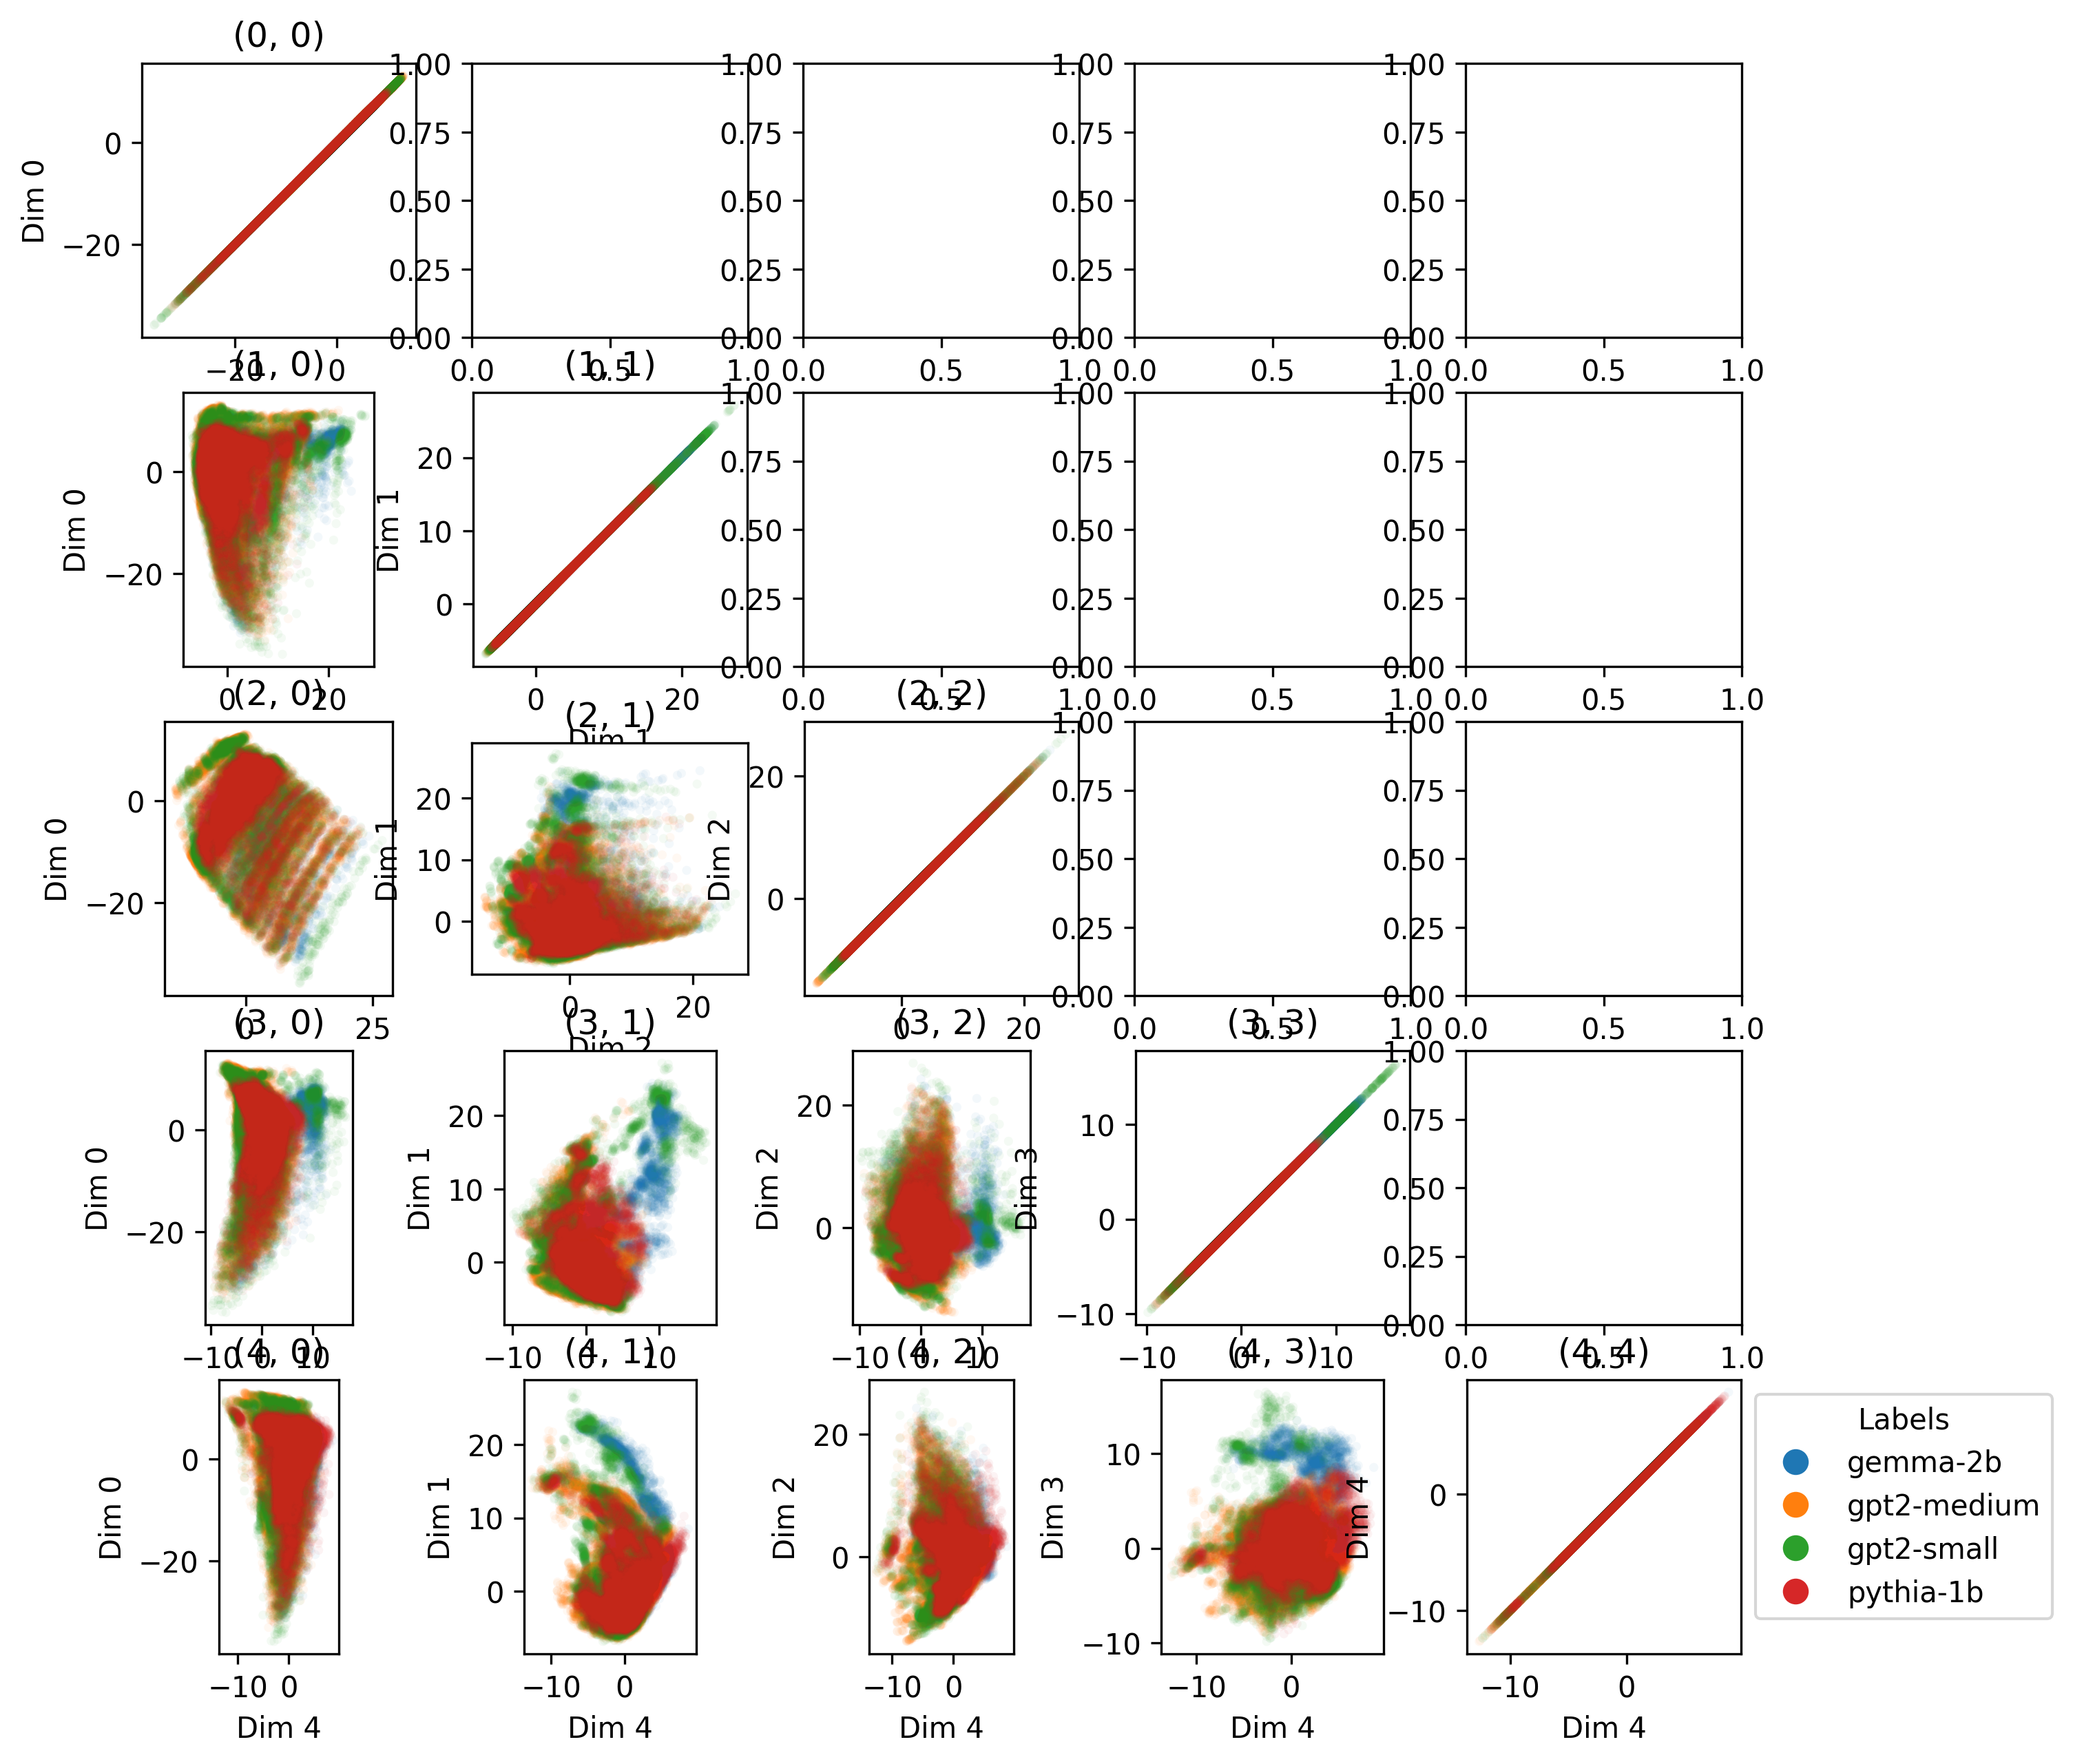

In [14]:

n_dims: int = 5
embed_fig, embed_ax = plt.subplots(
	n_dims,
	n_dims,
	figsize=(10, 10),
	dpi=300,
)
for i in range(0, n_dims):
	for j in range(0, i+1):
		plot_embedding(
			pca_data,
			DATA_SCALED["activation.model"],
			(i, j),
			alpha=0.05,
			marker_size=10,
			title=f"({i}, {j})",
			ax=embed_ax[i, j],
		)